In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-02-14/age_gaps.csv"
age_gaps = pd.read_csv(url)

age_gaps.columns = age_gaps.columns.str.lower()

# parse dates
date_cols = [c for c in age_gaps.columns if "birthdate" in c]
for c in date_cols:
    age_gaps[c] = pd.to_datetime(age_gaps[c], errors="coerce")

age_gaps.info()
age_gaps.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   movie_name          1155 non-null   object        
 1   release_year        1155 non-null   int64         
 2   director            1155 non-null   object        
 3   age_difference      1155 non-null   int64         
 4   couple_number       1155 non-null   int64         
 5   actor_1_name        1155 non-null   object        
 6   actor_2_name        1155 non-null   object        
 7   character_1_gender  1155 non-null   object        
 8   character_2_gender  1155 non-null   object        
 9   actor_1_birthdate   1155 non-null   datetime64[ns]
 10  actor_2_birthdate   1155 non-null   datetime64[ns]
 11  actor_1_age         1155 non-null   int64         
 12  actor_2_age         1155 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(6)
memory

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


# Data processing

Check missing value

In [ ]:
age_gaps.isna().sum()

,0
movie_name,0
release_year,0
director,0
age_difference,0
couple_number,0
actor_1_name,0
actor_2_name,0
character_1_gender,0
character_2_gender,0
actor_1_birthdate,0


Drop useless column

In [ ]:
age_gaps_copy = age_gaps.copy()
age_gaps_copy=age_gaps_copy.drop(columns=['actor_1_birthdate', 'actor_2_birthdate', 'couple_number'])

# Feature Engineering

Add new features

In [ ]:
#Add new feature: actor frequency
actors = pd.concat([age_gaps_copy["actor_1_name"], age_gaps_copy["actor_2_name"]]).dropna()
actor_counts = actors.value_counts()

age_gaps_copy["actor_1_freq"] = age_gaps_copy["actor_1_name"].map(actor_counts).fillna(0)
age_gaps_copy["actor_2_freq"] = age_gaps_copy["actor_2_name"].map(actor_counts).fillna(0)

age_gaps_copy["actor_freq_sum"] = (
    age_gaps_copy["actor_1_freq"] + age_gaps_copy["actor_2_freq"]
)

# add new feature: director frequency
director_col = "director"
director_counts = age_gaps_copy[director_col].value_counts()

age_gaps_copy["director_freq"] = (
    age_gaps_copy[director_col].map(director_counts).fillna(0)
)

#Add new feature: younger_age
age_gaps_copy['younger_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].min(axis=1)

#Add new feature: older_age
age_gaps_copy['order_age'] = age_gaps_copy[['actor_1_age', 'actor_2_age']].max(axis=1)

#Add new feature: mean_age_of_couple
age_gaps_copy['mean_age_of_couple'] = (age_gaps_copy['younger_age'] + age_gaps_copy['order_age'])/2

# add new column named " relative_age_gap"
age_gaps_copy['relative_age_gap'] = age_gaps_copy['age_difference']/age_gaps_copy['younger_age']

#Add new feature: relationship_type
age_gaps_copy["relationship_type"] = np.where(
    age_gaps_copy["character_1_gender"] == age_gaps_copy["character_2_gender"],
    "Same-gender",
    "Heterosexual"
)

#Add new feature: who_is_older
age_gaps_copy["who_is_older"] = np.where(
    age_gaps_copy["relationship_type"] != "Heterosexual",
   "Same-gender",
    np.where(
        age_gaps_copy["actor_1_age"] > age_gaps_copy["actor_2_age"],
        age_gaps_copy["character_1_gender"],
        np.where(
            age_gaps_copy["actor_2_age"] > age_gaps_copy["actor_1_age"],
            age_gaps_copy["character_2_gender"],
            "same_age"
        )
    )
)

#Add new feature: by_decade
age_gaps_copy["by_decade"] = (age_gaps_copy["release_year"] // 10) * 10


In [ ]:
age_gaps_copy.head()

,movie_name,release_year,director,age_difference,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age,...,actor_2_freq,actor_freq_sum,director_freq,younger_age,order_age,mean_age_of_couple,relative_age_gap,relationship_type,who_is_older,by_decade
0,Harold and Maude,1971,Hal Ashby,52,Ruth Gordon,Bud Cort,woman,man,75,23,...,1,2,1,23,75,49.0,2.260870,Heterosexual,woman,1970
1,Venus,2006,Roger Michell,50,Peter O'Toole,Jodie Whittaker,man,woman,74,24,...,1,2,3,24,74,49.0,2.083333,Heterosexual,man,2000
2,The Quiet American,2002,Phillip Noyce,49,Michael Caine,Do Thi Hai Yen,man,woman,69,20,...,2,3,2,20,69,44.5,2.450000,Heterosexual,man,2000
3,The Big Lebowski,1998,Joel Coen,45,David Huddleston,Tara Reid,man,woman,68,23,...,2,3,5,23,68,45.5,1.956522,Heterosexual,man,1990
4,Beginners,2010,Mike Mills,43,Christopher Plummer,Goran Visnjic,man,man,81,38,...,1,3,2,38,81,59.5,1.131579,Same-gender,Same-gender,2010


In [ ]:
age_gaps_copy.columns

Index(['movie_name', 'release_year', 'director', 'age_difference',
       'actor_1_name', 'actor_2_name', 'character_1_gender',
       'character_2_gender', 'actor_1_age', 'actor_2_age', 'actor_1_freq',
       'actor_2_freq', 'actor_freq_sum', 'director_freq', 'younger_age',
       'order_age', 'mean_age_of_couple', 'relative_age_gap',
       'relationship_type', 'who_is_older', 'by_decade'],
      dtype='object')

# Model 0: Baseline Model (all non-textual features)

In [ ]:
#build cluster matrix
dir_cluster_model0 = age_gaps_copy[[
    "age_difference",
    "mean_age_of_couple",
    "relative_age_gap"
]]
dir_cluster_model0

,age_difference,mean_age_of_couple,relative_age_gap
0,52,49.0,2.260870
1,50,49.0,2.083333
2,49,44.5,2.450000
3,45,45.5,1.956522
4,43,59.5,1.131579
...,...,...,...
1150,0,23.0,0.000000
1151,0,42.0,0.000000
1152,0,30.0,0.000000
1153,0,21.0,0.000000


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
dir_model0_normalized = pd.DataFrame(sc.fit_transform(dir_cluster_model0), columns=dir_cluster_model0.columns)

dir_model0_normalized

,age_difference,mean_age_of_couple,relative_age_gap
0,4.887011,1.693628,5.471972
1,4.651921,1.693628,4.956601
2,4.534377,1.132271,6.020999
3,4.064198,1.257017,4.588479
4,3.829108,3.003460,2.193749
...,...,...,...
1150,-1.225315,-1.549765,-1.091117
1151,-1.225315,0.820407,-1.091117
1152,-1.225315,-0.676544,-1.091117
1153,-1.225315,-1.799257,-1.091117


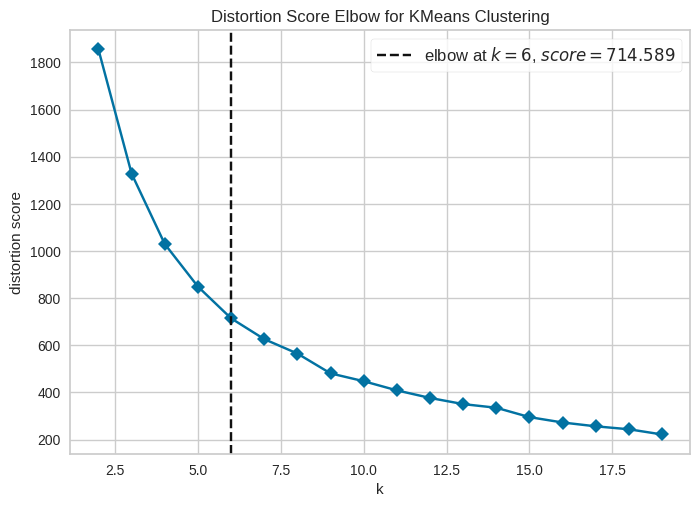

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(dir_model0_normalized)
visualizer.show()

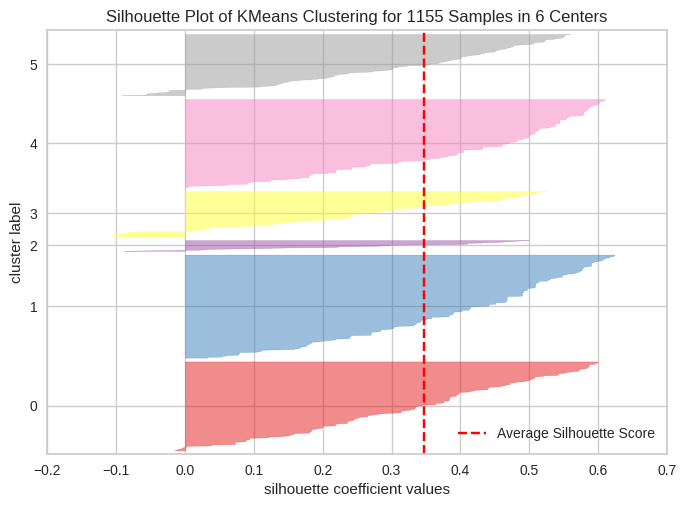

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1155 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
n_clusters_kmeans=6

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(dir_model0_normalized)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

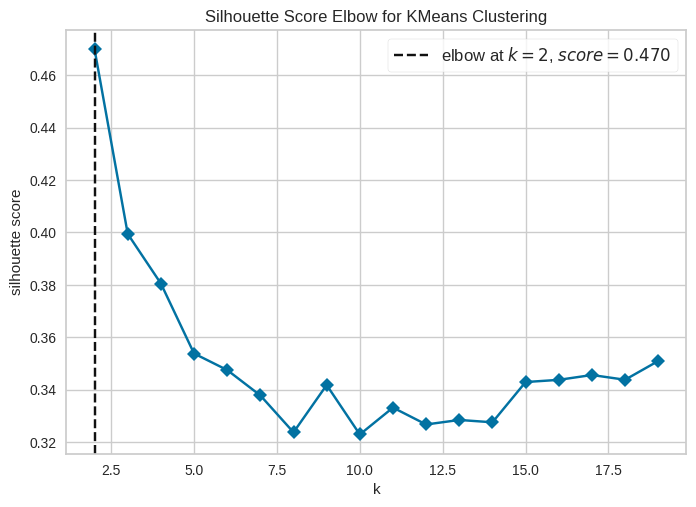

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='silhouette', timings=False, random_state=42
)

visualizer.fit(dir_model0_normalized)
visualizer.show()

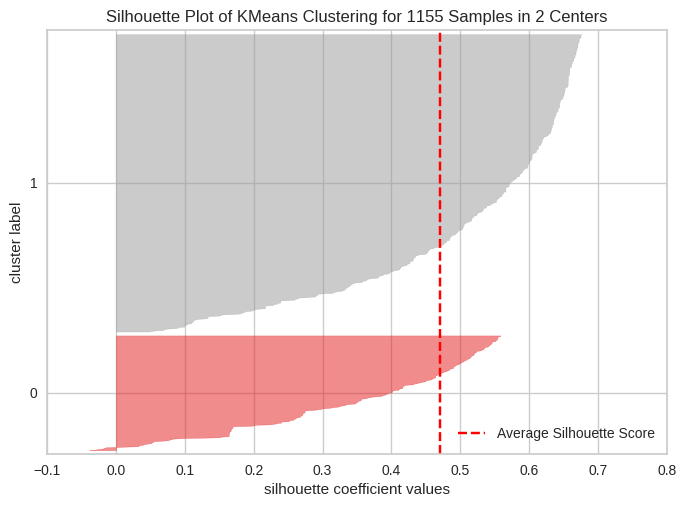

Average silhouette score: 0.4697771528619048


In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
n_clusters_kmeans=2

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(dir_model0_normalized)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

print("Average silhouette score:", visualizer.silhouette_score_)

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels_raw = kmeans.fit_predict(dir_model0_normalized)

# PCA

In [ ]:
!pip install psynlig -q

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca=PCA()
pca_model0 = pca.fit_transform(dir_model0_normalized)

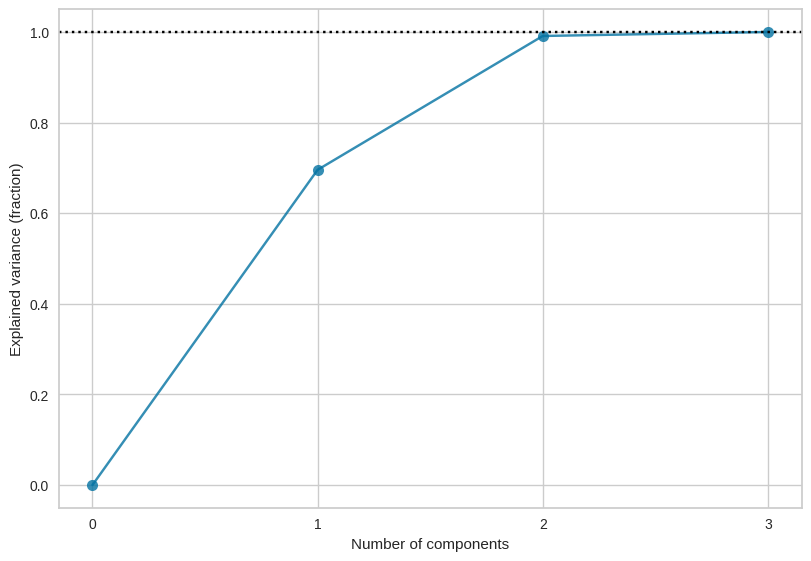

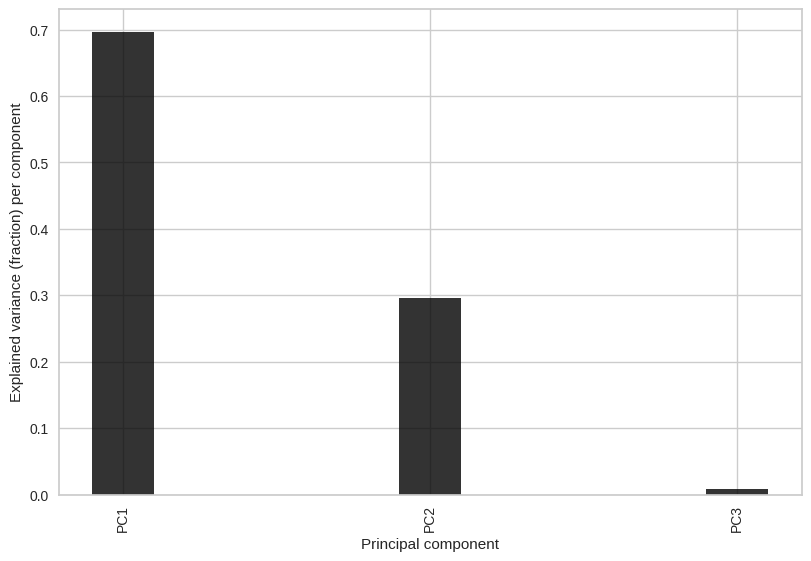

In [ ]:
from matplotlib import pyplot as plt
from psynlig import (pca_explained_variance, pca_explained_variance_bar,)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    pca,
    width=0.2,
    alpha=0.8,
    color='black',
)

plt.show()

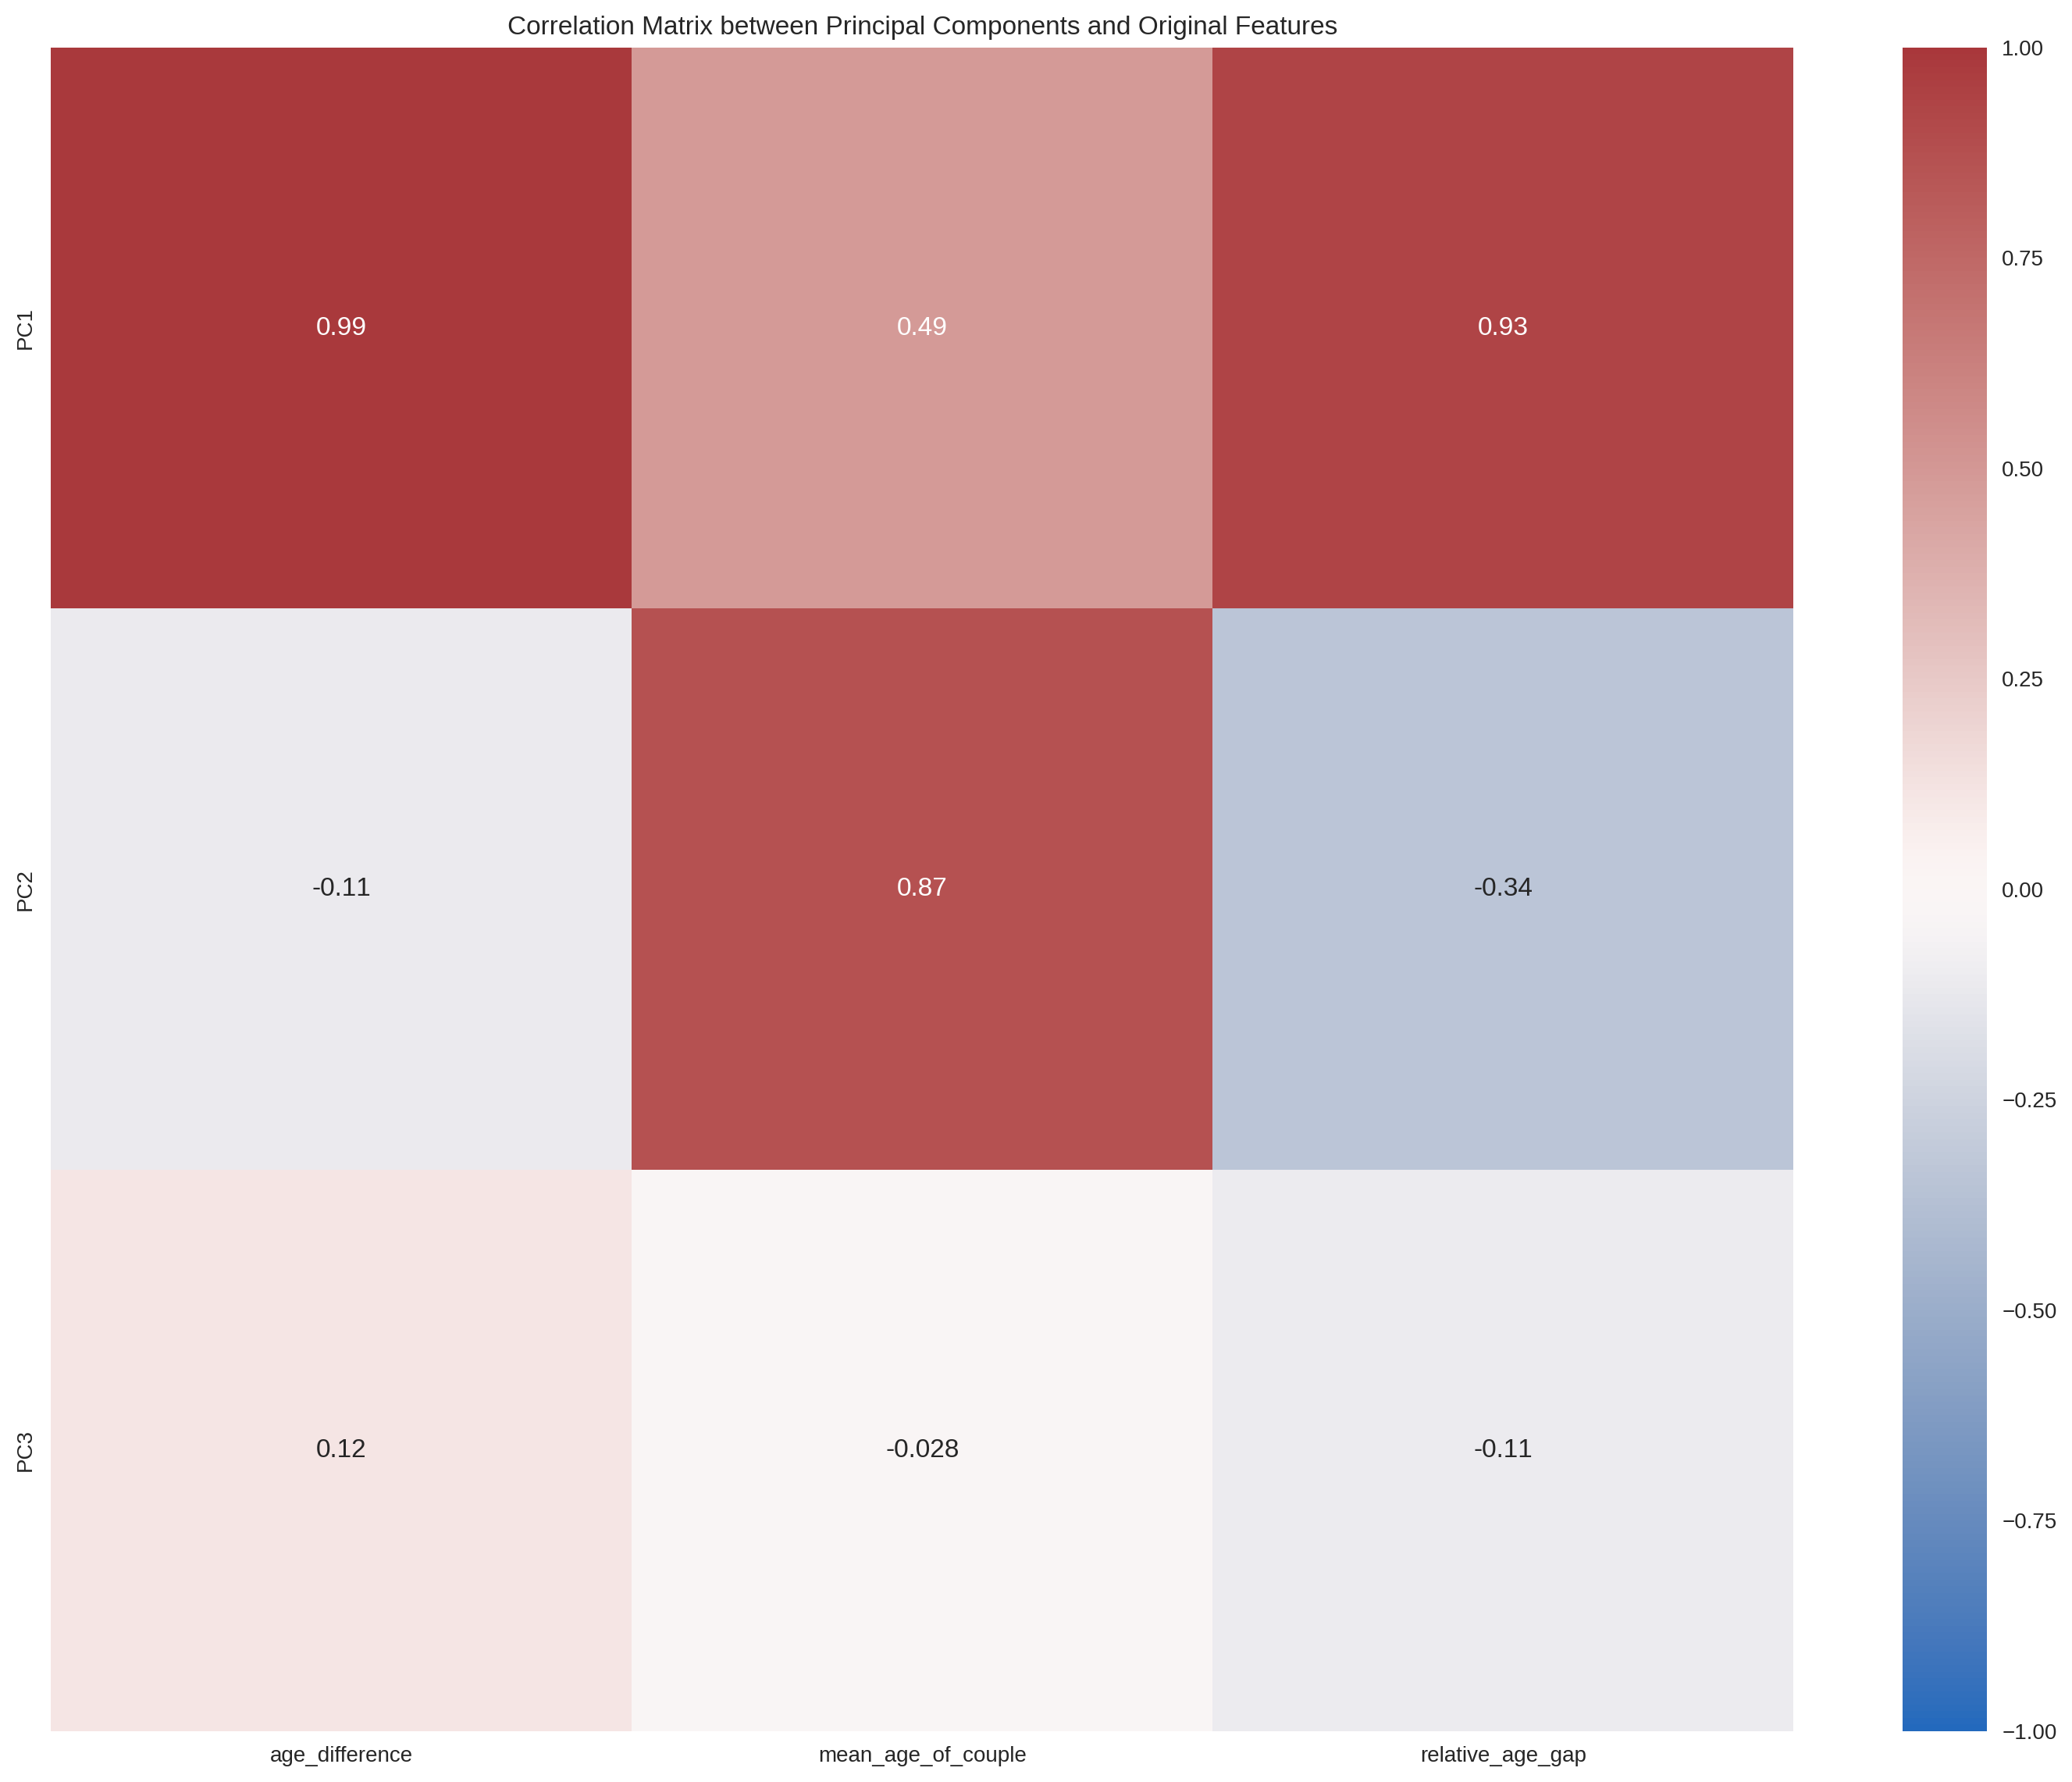

In [ ]:
import seaborn as sns
# Data represented in terms of PCs
transformed_data = pd.DataFrame(pca.transform(dir_model0_normalized), columns = ['PC' + str(i+1) for i in range(len(pca.components_))])

# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data, dir_model0_normalized.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data.columns, dir_model0_normalized.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

Check if Cluster better after PCA

In [ ]:
pca1n2 = PCA(n_components=2)
X_pca = pca1n2.fit_transform(dir_model0_normalized)

In [ ]:
kmeans_pca1n2 = KMeans(n_clusters=2, random_state=42)
labels_pca=kmeans_pca1n2.fit_predict(X_pca)

In [ ]:
from sklearn.metrics import silhouette_score
sil_pca = silhouette_score(X_pca, labels_pca)
print("Silhouette after PCA:", sil_pca)

Silhouette after PCA: 0.47135125891368074


Silhouette score has slightly raise after PCA from 0.46 to 0.47

# Text Mining

Because the distribution of relationship types is extremely imbalanced, any model built under these conditions would likely focus primarily on the majority group. As a result, the predictions would not be reliable or sufficiently accurate, so this approach is not appropriate.

In [ ]:
age_gaps_copy["relationship_type"].value_counts(normalize=True)

,proportion
relationship_type,
Heterosexual,0.980087
Same-gender,0.019913


## Exploratory text mining

Do movie titles associated with same-gender and heterosexual relationships use different language?

In [ ]:
movie_df  = age_gaps_copy[["movie_name"]]
relation_df = age_gaps_copy[["relationship_type"]]

In [ ]:
movie_df

,movie_name
0,Harold and Maude
1,Venus
2,The Quiet American
3,The Big Lebowski
4,Beginners
...,...
1150,The Hunger Games: Catching Fire
1151,The Lake House
1152,Tolkien
1153,Transformers


In [ ]:
relation_df

,relationship_type
0,Heterosexual
1,Heterosexual
2,Heterosexual
3,Heterosexual
4,Same-gender
...,...
1150,Heterosexual
1151,Heterosexual
1152,Heterosexual
1153,Heterosexual


In [ ]:
movie_df["movie_name"].nunique()

830

In [ ]:
df= movie_df.join(relation_df)
df_nodu = df.drop_duplicates(subset=["movie_name"])  # 以片名為主的去重

In [ ]:
df_nodu

,movie_name,relationship_type
0,Harold and Maude,Heterosexual
1,Venus,Heterosexual
2,The Quiet American,Heterosexual
3,The Big Lebowski,Heterosexual
4,Beginners,Same-gender
...,...,...
1146,Speed,Heterosexual
1150,The Hunger Games: Catching Fire,Heterosexual
1151,The Lake House,Heterosexual
1152,Tolkien,Heterosexual


In [ ]:
df_nodu['relationship_type'].value_counts()

,count
relationship_type,
Heterosexual,814
Same-gender,16


## Text Cleaning

In [ ]:
# lowercase
df_nodu["movie_name"] = df_nodu["movie_name"].str.lower()
# remove punctuation
df_nodu["movie_name"] = df_nodu["movie_name"].str.replace(r"[^\w\s]", "", regex=True)
df_nodu

/tmp/ipython-input-1959815980.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nodu["movie_name"] = df_nodu["movie_name"].str.lower()
/tmp/ipython-input-1959815980.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nodu["movie_name"] = df_nodu["movie_name"].str.replace(r"[^\w\s]", "", regex=True)


,movie_name,relationship_type
0,harold and maude,Heterosexual
1,venus,Heterosexual
2,the quiet american,Heterosexual
3,the big lebowski,Heterosexual
4,beginners,Same-gender
...,...,...
1146,speed,Heterosexual
1150,the hunger games catching fire,Heterosexual
1151,the lake house,Heterosexual
1152,tolkien,Heterosexual


## Tokenization

In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize

tokens_df = df_nodu.apply(
    lambda x: word_tokenize(x["movie_name"]),
    axis=1
).to_frame(name="tokens")

tokens_df["tokens"].iloc[0]

['harold', 'and', 'maude']

In [ ]:
tokens_df.head()

,tokens
0,"[harold, and, maude]"
1,[venus]
2,"[the, quiet, american]"
3,"[the, big, lebowski]"
4,[beginners]


In [ ]:
from nltk.tokenize.treebank import TreebankWordDetokenizer

detokenized_df = tokens_df.apply(
    lambda x: TreebankWordDetokenizer().detokenize(x["tokens"]), axis=1).to_frame(name="detokenized")

detokenized_df["detokenized"].loc[0]

'harold and maude'

## BoW and Vectorizerization

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words="english",
    lowercase=True,
    min_df=2
)

cv.fit(df_nodu["movie_name"])
print("Number of tokens:", len(cv.vocabulary_))

Number of tokens: 211


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
data_vectorized = cv.transform(df_nodu["movie_name"])

dtm = pd.DataFrame(
    data_vectorized.toarray(),
    columns=cv.get_feature_names_out(),
    index=df_nodu.index
)

dtm.head()

,10,12,2,affair,age,air,almighty,america,american,angel,...,wolverine,woman,women,wonder,wood,world,xmen,year,york,zombieland
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_nodu.columns

Index(['movie_name', 'relationship_type'], dtype='object')

In [ ]:
same_mask = (df_nodu["relationship_type"] == "Same-gender").to_numpy()
diff_mask = (df_nodu["relationship_type"] == "Heterosexual").to_numpy()

same_mean = dtm[same_mask].mean()
diff_mean = dtm[diff_mask].mean()
difference = same_mean - diff_mean

top_same = difference[difference > 0].sort_values(ascending=False).head(20)
top_diff = difference[difference < 0].sort_values().head(20)

top_same, top_diff

(rock       0.061271
 monster    0.061271
 color      0.060043
 heart      0.060043
 blue       0.058814
 man        0.046529
 love       0.042844
 dtype: float64,
 girl       -0.013514
 american   -0.011057
 day        -0.008600
 big        -0.007371
 la         -0.007371
 good       -0.007371
 walk       -0.007371
 time       -0.007371
 woman      -0.007371
 black      -0.006143
 wedding    -0.006143
 story      -0.006143
 new        -0.006143
 war        -0.006143
 dark       -0.006143
 days       -0.006143
 star       -0.006143
 world      -0.006143
 wonder     -0.004914
 nights     -0.004914
 dtype: float64)

# Cosion silimilarity

## Min_df=2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = np.round(cosine_similarity(dtm), 2)

cos_sim_df = pd.DataFrame(
    cos_sim,
    index=df_nodu.index,
    columns=df_nodu.index
)

cos_sim_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1133,1135,1137,1141,1142,1146,1150,1151,1152,1153
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


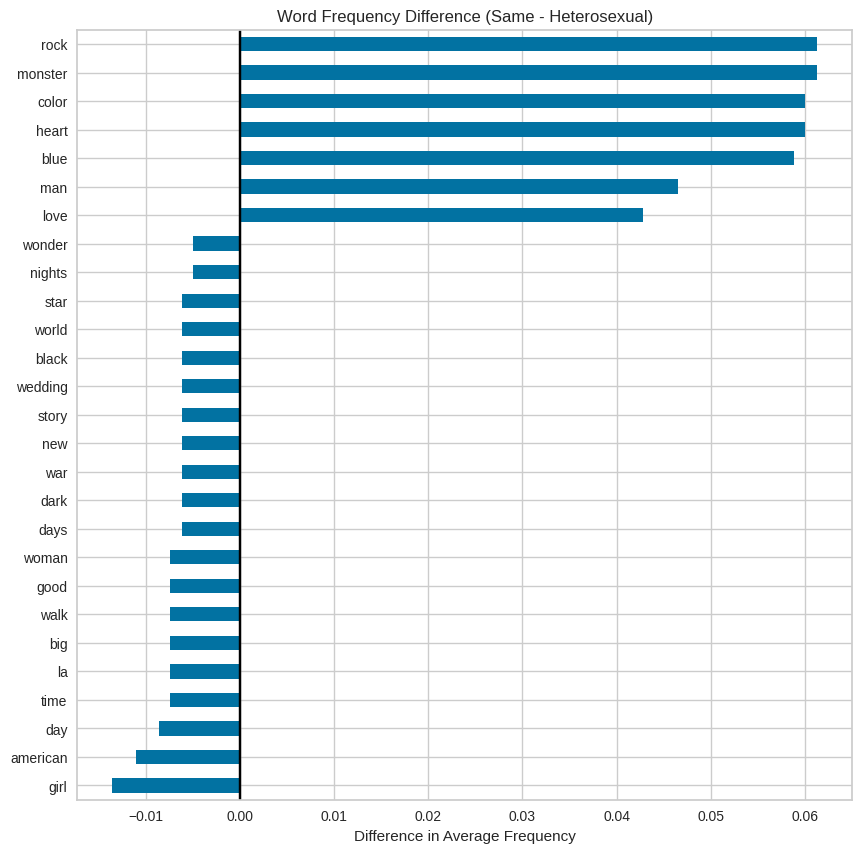

In [ ]:
plt.figure(figsize=(10,10))

combined = pd.concat([top_same, top_diff])
combined.sort_values().plot(kind="barh")

plt.title("Word Frequency Difference (Same - Heterosexual)")
plt.xlabel("Difference in Average Frequency")
plt.axvline(0, color="black")  # 中線
plt.show()

##Min_df=1

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv_min1= CountVectorizer(
    tokenizer=word_tokenize,
    stop_words="english",
    lowercase=True,
    min_df=1
)

cv_min1.fit(df_nodu["movie_name"])
print("Number of tokens:", len(cv_min1.vocabulary_))

Number of tokens: 1130


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
data_vectorized = cv_min1.transform(df_nodu["movie_name"])

dtm_min1 = pd.DataFrame(
    data_vectorized.toarray(),
    columns=cv_min1.get_feature_names_out(),
    index=df_nodu.index #建 dtm 時指定 index
)

dtm_min1.head()

,10,12,13,15,2,27,30,300,3000,40year,...,yogi,york,young,z,zoe,zohan,zombieland,zoo,zoolander,zorro
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
same_mean_min1 = dtm_min1[same_mask].mean()
diff_mean_min1 = dtm_min1[diff_mask].mean()

difference_min1 = same_mean_min1 - diff_mean_min1

top_same_min1 = (difference_min1[difference_min1 > 0].sort_values(ascending=False).head(20))
top_diff_min1 = (difference_min1[difference_min1 < 0].sort_values().head(20))

top_same_min1, top_diff_min1

(ages          0.062500
 beginners     0.062500
 candelabra    0.062500
 carol         0.062500
 chloe         0.062500
 favourite     0.062500
 warmest       0.062500
 freeheld      0.062500
 imagine       0.062500
 heights       0.062500
 phillip       0.062500
 normal        0.062500
 morris        0.062500
 milk          0.062500
 single        0.062500
 monster       0.061271
 rock          0.061271
 color         0.060043
 heart         0.060043
 blue          0.058814
 dtype: float64,
 girl       -0.013514
 american   -0.011057
 day        -0.008600
 woman      -0.007371
 big        -0.007371
 good       -0.007371
 walk       -0.007371
 time       -0.007371
 la         -0.007371
 black      -0.006143
 new        -0.006143
 story      -0.006143
 star       -0.006143
 war        -0.006143
 wedding    -0.006143
 world      -0.006143
 dark       -0.006143
 days       -0.006143
 nights     -0.004914
 little     -0.004914
 dtype: float64)

In [ ]:
cos_sim = np.round(cosine_similarity(dtm＿min1), 2)

cos_sim_df = pd.DataFrame(
    cos_sim,
    index=df_nodu.index,      # 例如 movieId 或原本的 row index
    columns=df_nodu.index
)

cos_sim_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1133,1135,1137,1141,1142,1146,1150,1151,1152,1153
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


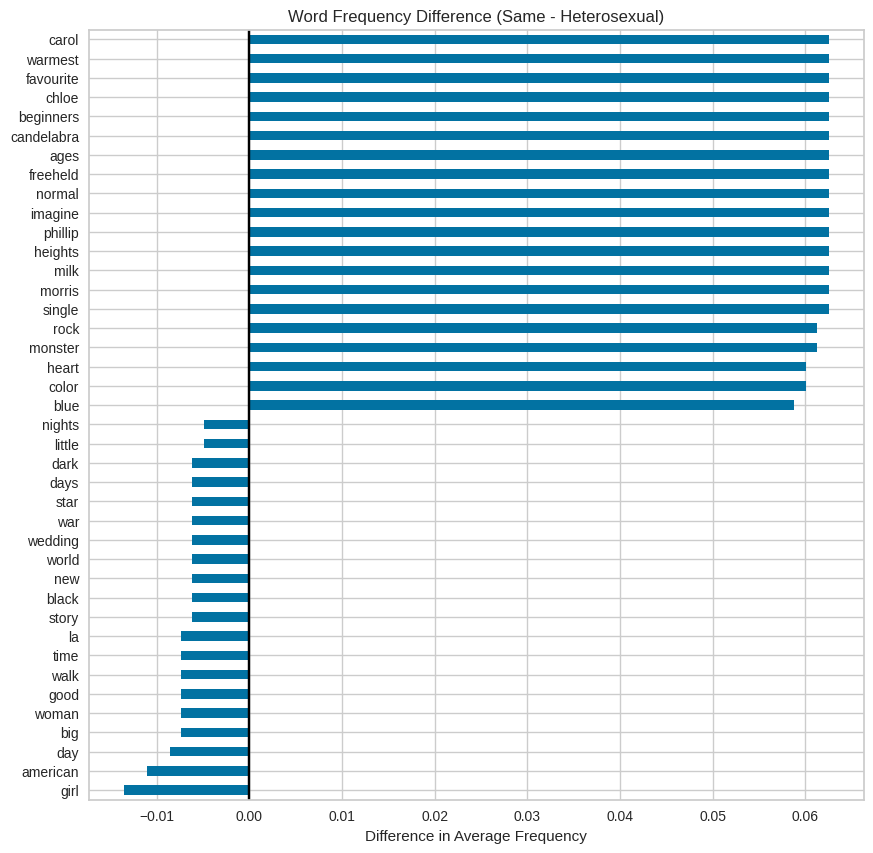

In [ ]:
plt.figure(figsize=(10,10))

combined = pd.concat([top_same＿min1, top_diff_min1])
combined.sort_values().plot(kind="barh")

plt.title("Word Frequency Difference (Same - Heterosexual)")
plt.xlabel("Difference in Average Frequency")
plt.axvline(0, color="black")
plt.show()